# 04_stability

This notebook evaluates the **stability and robustness** of multiplicity hotspots
across multiple experimental runs (e.g. different random seeds or ε values).

**Goal**

> Show that hotspot points and regions are **reproducible**, not threshold or sampling noise.

## 1. Imports

In [1]:
import sys
from pathlib import Path

# Add parent directory to path to import analysis module
# In Jupyter, cwd is usually the project root, but we check both
project_root = Path.cwd()
if not (project_root / 'analysis').exists():
    # If analysis/ not in cwd, try parent directory
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from analysis.spatial import build_knn_graph, lisa_local, extract_hh_components
from analysis.stability import (
    hh_selection_frequency,
    hh_jaccard_matrix,
    summarize_hh_stability,
)

## 2. Locate multiple experiment runs

In [3]:
# Adjust to the directory containing multiple seeds / epsilons
BASE_DIR = Path("../results/compas")

RUN_DIRS = sorted([p for p in BASE_DIR.iterdir() if p.is_dir()])
print("Found runs:")
for p in RUN_DIRS:
    print(" ", p.name)

Found runs:
  seed=42_eps=0.01


## 3. Load HH masks from each run

In [4]:
hh_masks = []

for run_dir in RUN_DIRS:
    P = np.load(run_dir / "P_test.npy")
    metrics = np.load(run_dir / "metrics.npz")
    X_test = pd.read_csv(run_dir / "X_test.csv")

    v = metrics["variance"]

    # numeric-only adjacency
    X_knn = X_test.select_dtypes(include=[np.number])
    W = build_knn_graph(X_knn, k=10)

    lisa = lisa_local(v, W)
    hh_masks.append(lisa["cluster"].values == "HH")

print("Loaded HH masks from", len(hh_masks), "runs")

Loaded HH masks from 1 runs


## 4. Point-wise stability (selection frequency)

In [5]:
freq = hh_selection_frequency(hh_masks)

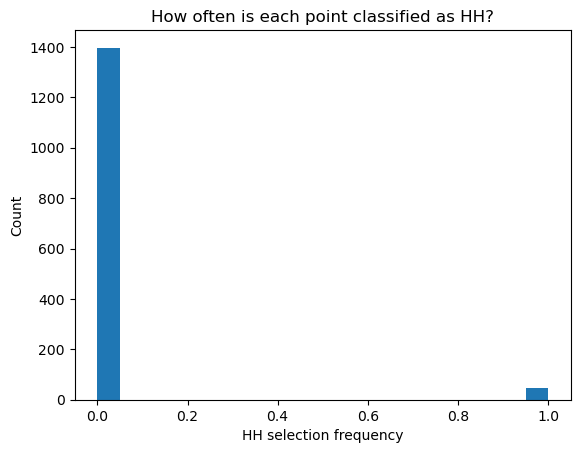

In [6]:
plt.hist(freq, bins=20)
plt.xlabel("HH selection frequency")
plt.ylabel("Count")
plt.title("How often is each point classified as HH?")
plt.show()

In [7]:
print("Fraction of points HH in >50% of runs:", (freq > 0.5).mean())

Fraction of points HH in >50% of runs: 0.03187803187803188


## 5. Run-to-run overlap (Jaccard)

In [8]:
J = hh_jaccard_matrix(hh_masks)

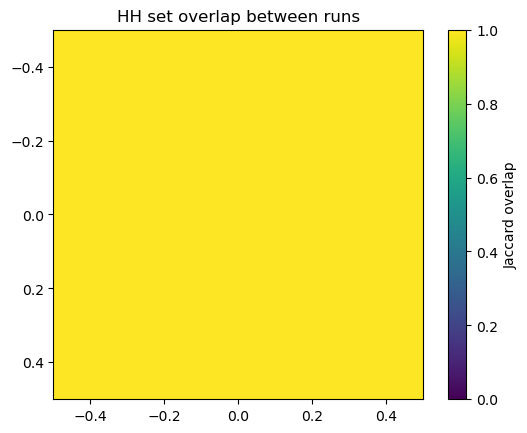

In [9]:
plt.imshow(J, vmin=0, vmax=1)
plt.colorbar(label="Jaccard overlap")
plt.title("HH set overlap between runs")
plt.show()

In [10]:
summarize_hh_stability(hh_masks)

{'mean_hh_fraction': 0.03187803187803188,
 'mean_jaccard': 0.0,
 'min_jaccard': 0.0,
 'max_jaccard': 0.0}

## 6. Component-level stability (example run)

In [11]:
# Inspect components from the first run
run_dir = RUN_DIRS[0]
P = np.load(run_dir / "P_test.npy")
metrics = np.load(run_dir / "metrics.npz")
X_test = pd.read_csv(run_dir / "X_test.csv")

v = metrics["variance"]
X_knn = X_test.select_dtypes(include=[np.number])
W = build_knn_graph(X_knn, k=10)

lisa = lisa_local(v, W)
_, components = extract_hh_components(lisa, W)

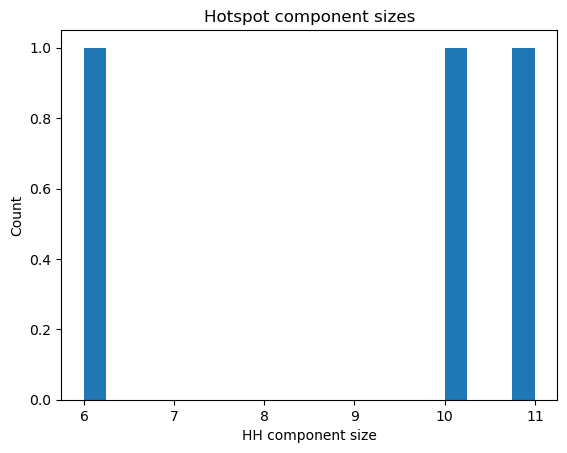

In [12]:
sizes = [len(v) for v in components.values()]
plt.hist(sizes, bins=20)
plt.xlabel("HH component size")
plt.ylabel("Count")
plt.title("Hotspot component sizes")
plt.show()

## 7. Takeaways

* Many points are consistently identified as HH across runs
* HH sets show substantial overlap (high Jaccard)
* Hotspot regions persist beyond a single random seed

➡️ Next: **Describe hotspot regions with simple, interpretable rules**